<a href="https://colab.research.google.com/github/AlecS12/CatE/blob/master/notebooks/IVADOBootcamp_Day4_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from itertools import combinations, permutations, chain
import matplotlib.pyplot as plt
from math import factorial, comb
import timeit
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Cooperative Games

<div class="alert alert-warning">
⚠️ <strong>Warning</strong><br>
The following implementations are <strong>not efficient AT ALL</strong> (we could easily do a <strong>WAY</strong> better job).
    
-> Goal of this notebook is to simplify the code in order to understand the main ideas behind cooperative games.
</div>

A cooperative game is defined as a tuple $(D,v)$ where :
- $D = \{1,\dots, d\}$ is a set of players ;
- $\mathcal{P}_D$ is the *power-set* of $D$ (i.e., the collection of **coalitions** of players) ;
- $v : \mathcal{P}_D \rightarrow \mathbb{R}$ is the *value function*, that assigns a value to each of the players.

## Players and coalitions

Let's start by defining a simple game with $3$ players.

In [2]:
# Let's define the set of players
players = [1,2,3]

# Let's define the set coalitions
coalitions = [set(), {1}, {2}, {3}, {1,2}, {1,3}, {2,3}, {1,2,3}]

Let's define a function that returns the power-set from a number of players $d$ :

In [3]:
def get_coalitions(n_players: int):
    """
    Generates the set of coalitions (power-set) for a given number of players.

    Args:
        n_players (int): The total number of players.

    Returns:
        list[set]: A list of sets, where each set is a coalition.
    """
    if n_players <= 0:
        raise ValueError("Number of players must be positive.")

    player_indices = range(1, n_players + 1)
    return [set(coalition) for size in range(n_players + 1) for coalition in combinations(player_indices, size)]

# Example for 3 players
coalitions = get_coalitions(3)
print(f"Coalitions for 3 players: {coalitions}")

Coalitions for 3 players: [set(), {1}, {2}, {3}, {1, 2}, {1, 3}, {2, 3}, {1, 2, 3}]


The number of coalitions **grows exponentially** with the number of players :

In [4]:
# Number of players from 1 to 20
N_players = [x+1 for x in range(20)]

# Associated number of coalitions
N_coalitions = [len(get_coalitions(x)) for x in N_players]
N_coalitions

[2,
 4,
 8,
 16,
 32,
 64,
 128,
 256,
 512,
 1024,
 2048,
 4096,
 8192,
 16384,
 32768,
 65536,
 131072,
 262144,
 524288,
 1048576]

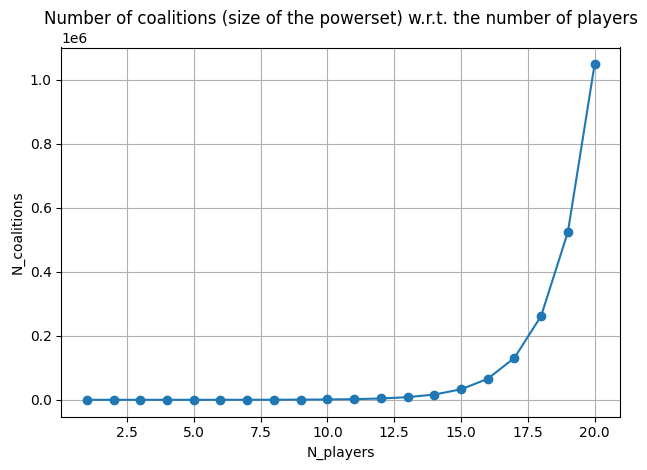

In [5]:
plt.figure()
plt.plot(N_players, N_coalitions, marker='o')
plt.xlabel("N_players")
plt.ylabel("N_coalitions")
plt.title("Number of coalitions (size of the powerset) w.r.t. the number of players")
plt.grid(True)
plt.tight_layout()
plt.show()

In fact, for $d$ players, the number of coalitions is exactly $2^d$!

To get a feel on the order of magnitude on how **fast** the number of coalitions grows w.r.t. $d$, here is a quick table:

| Number of players ($d$) | Number of coalitions $(2^d)$ | $2^d$ seconds is about... |
|---:|---:|---:|
| 2 | 4 | 4 s |
| 5 | 32 | 32 s |
| 10 | 1,024 | 17 min 4 s |
| 20 | 1,048,576 | $\approx$ 12.14 days |
| 50 | $1.13\times 10^{15}$ | $\approx$ 35.7 million years |
| 100 | $1.27\times 10^{30}$ | $\approx$ $4.02\times 10^{22}$ years |
| 300 | $2.04\times 10^{90}$ | $\approx$ $6.45\times 10^{82}$ years |

As a point of comparison, **the universe is approximately $1.379 \times 10^{10}$ years old**.



## Value function

Now, let's define our first value function. Let's pick a simple one: $v(A) = \textrm{card}(A)$, i.e. the value of a coalition is the number of players it composes.

In [6]:
# Start with 3 players
d = 3

# We define a first value function : the number of players in a coalition
def coalition_size(coalition):
    """
    Computes the number of players in a coalition as a value function

    Args:
        coalition (set): A set of players.

    Returns:
        int: The number of players in the coalition.
    """
    return(len(coalition))

# Define the set of coalitions
coalitions = get_coalitions(d)

# Compute the value of every possible coalition
values = [coalition_size(x) for x in coalitions]

# Let's print what the value is for each coalition
for i in range(len(coalitions)):
  print("Coalition : ", str(coalitions[i]), "\t - \t Value : ", str(values[i]))

Coalition :  set() 	 - 	 Value :  0
Coalition :  {1} 	 - 	 Value :  1
Coalition :  {2} 	 - 	 Value :  1
Coalition :  {3} 	 - 	 Value :  1
Coalition :  {1, 2} 	 - 	 Value :  2
Coalition :  {1, 3} 	 - 	 Value :  2
Coalition :  {2, 3} 	 - 	 Value :  2
Coalition :  {1, 2, 3} 	 - 	 Value :  3


## Worth and dual game

Let $(D,v)$ be a cooperative game, and define the value function:

$$ \forall A \in \mathcal{P}_D, \quad w(A) = v(D) - v(D \setminus A)$$

The cooperative game $(D,w)$ is then called the **dual game** of $(D,v)$. Sometimes, $w$ is called the *worth* of a cooperative game. Notice additionnally that $v(D) = w(D)$: these two value functions lead to decomposing the same quantity of interest.


Let's define the worth of our initial game.

In [8]:
# Let's define the dual of our first value function
def dual_value_function(coalition: set, value_function, d: int):
    """
    Computes the number of players in a coalition as a value function

    Args:
        coalition (set): A set of players.
        value_function: A value function.
        d (int): The total number of players.

    Returns:
        int: Returns the dual of the value function.
    """
    # Define he grand coalition from d
    D = set({x+1 for x in range(d)})

    # Define the coalition D\A
    D_A = D - coalition

    # We return the value function of D substracted from the value function of D\A
    return(value_function(D) - value_function(D_A))

# Define the set of teams/coalitions
coalitions = get_coalitions(d)

# Compute the dual value for every possible coalition for the coalition size value function
worths = [dual_value_function(x, coalition_size, d) for x in coalitions]

# Let's print what the value is for each coalition
for i in range(len(coalitions)):
  print("Coalition : ", str(coalitions[i]), "\t - \t Worth : ", str(worths[i]))

Coalition :  set() 	 - 	 Worth :  0
Coalition :  {1} 	 - 	 Worth :  1
Coalition :  {2} 	 - 	 Worth :  1
Coalition :  {3} 	 - 	 Worth :  1
Coalition :  {1, 2} 	 - 	 Worth :  2
Coalition :  {1, 3} 	 - 	 Worth :  2
Coalition :  {2, 3} 	 - 	 Worth :  2
Coalition :  {1, 2, 3} 	 - 	 Worth :  3


In this particular case, we have that $v(A) = w(A)$! (You can try to prove it!) However, it is not the case in general : the worth usually differs from the value.

## Harsanyi dividends

The Harsanyi dividends quantify the *added-value* of a coalition. They are defined as:
$$\forall A \in \mathcal{P}_D, \quad D_v(A) = \sum_{B \in \mathcal{P}_A} (-1)^{|A|-|B|}v(B) = v(A) - \sum_{B \in \mathbb{P}_A} D_v(B)$$

Hence, with the evaluation of the value function, one can easily compute the dividends:

In [9]:
def compute_harsanyi_dividend(coalition: set, value_function, d: int):
    """
    Calculates the Harsanyi dividend of a specific coalition.

    Args:
        coalition (set): The subset of players to evaluate.
        value_function: A value function.
        d (int): The total number of players.

    Returns:
        float: The dividend value.
    """
    # Returns zero for the emptyset
    if not coalition:
        return 0.0


    dividend = 0.0
    # We iterate through all subsets of the current coalition to apply the inclusion-exclusion principle
    all_coalitions = get_coalitions(d)
    for subset in all_coalitions:
        if subset.issubset(coalition):
            # The formula is: sum_{B subset A} (-1)^(|A|-|B|) * v(B)
            weight = (-1)**(len(coalition) - len(subset))
            dividend += weight * value_function(subset)
    return dividend

# Define the set of teams/coalitions
coalitions = get_coalitions(d)

# Compute the dividend for every coalition
dividends = [compute_harsanyi_dividend(x, coalition_size, d) for x in coalitions]
dividends_dual = [compute_harsanyi_dividend(x, coalition_size, d) for x in coalitions]

# Let's print what the value is for each coalition
for i in range(len(coalitions)):
  print("Coalition : ", str(coalitions[i]), "\t - \t Dividend : ", str(dividends[i]))

Coalition :  set() 	 - 	 Dividend :  0.0
Coalition :  {1} 	 - 	 Dividend :  1.0
Coalition :  {2} 	 - 	 Dividend :  1.0
Coalition :  {3} 	 - 	 Dividend :  1.0
Coalition :  {1, 2} 	 - 	 Dividend :  0.0
Coalition :  {1, 3} 	 - 	 Dividend :  0.0
Coalition :  {2, 3} 	 - 	 Dividend :  0.0
Coalition :  {1, 2, 3} 	 - 	 Dividend :  0.0


# Allocations


Now, we leverage cooperative games in order to compute allocations.

## Harsanyi set

Recall that an allocation in the Harsanyi set can be written as:
$$\phi(i) = \sum_{A \in \mathcal{P}(D)} \lambda_i(A) \mathcal{D}_v(A) $$
where $\lambda_i(A)$ is the **weight-system**.

First, we can compute the Shapley values using the Harsanyi formulation. It amounts to the weight system $\lambda_i(A) = 1/|A|$.

In [10]:
def shapley_weight_system(value_function, player: int, coalition: set):
    """
    Weight system (Harsanyi set) for the Shapley value.

    Args:
        value_function: Not used here
        player (int): A player.
        coalition (set): The subset of players to evaluate.

    Returns:
        float: Returns 1/len(coalition) if the player is in the coalition, 0 otherwise
    """
    if player in coalition:
        return 1.0 / len(coalition)
    else:
        return 0.0

def get_harsanyi_allocation(value_function, n_players: int, weight_system):
    """
    Computes an allocation using the Harsanyi set formula.

    Args:
        player (int): A player.
        coalition (set): The subset of players to evaluate.

    Returns:
        float: Returns 1/len(coalition) if the player is in the coalition, 0 otherwise
    """
    # Define all the coalitions
    coalitions = get_coalitions(n_players)

    # Initialize the allocation vector
    allocation = [0.0] * n_players

    # Pre-calculate dividends in a dictionnary (for efficiency)
    ## The key is a coalition, the value is its Harsanyi dividend
    dividends_dict = {frozenset(c): compute_harsanyi_dividend(c, value_function, n_players) for c in coalitions}

    for i in range(n_players):
        player_id = i + 1
        for coalition in coalitions:
            if not coalition: continue # Skip the case of the emptyset (because we assume v(\emptyset)=0)
            dividend = dividends_dict[frozenset(coalition)]
            allocation[i] += weight_system(value_function, player_id, coalition) * dividend

    return allocation

# Quick test with the simple cardinality value function
print(f"Shapley values (Harsanyi) for the CoalitionSize value Function: {get_harsanyi_allocation(coalition_size, 3, shapley_weight_system)}")

Shapley values (Harsanyi) for the CoalitionSize value Function: [1.0, 1.0, 1.0]


Now, let's compute the Proportional Shapley values, it amounts to the weight system:

$$\lambda_i(A) = \frac{|v(i)|}{\sum_{j \in A} |v(j)|}$$

In [11]:
def proportional_shapley_weight_system(value_function, player: int, coalition: set):
    """
    Weight system for the proportional Shapley value.

    Args:
        value_function: A value function.
        player (int): A player.
        coalition (set): The subset of players to evaluate.

    Returns:
        float: Returns 1/len(coalition) if the player is in the coalition, 0 otherwise
    """
    if player in coalition:
        numerator = abs(value_function({player}))
        denominator = sum([abs(value_function({j})) for j in coalition])
        return numerator/denominator
    else:
        return 0.0

print(f"Proportional Shapley values (Harsanyi) for the CoalitionSize value Function: {get_harsanyi_allocation(coalition_size, 3, proportional_shapley_weight_system)}")

Proportional Shapley values (Harsanyi) for the CoalitionSize value Function: [1.0, 1.0, 1.0]


## Weber set

Recall that allocations in the Weber set are computed as follows:
$$\phi(i) = \sum_{\pi \in \mathcal{S}_D} p(\pi) \left[ v\left( \{\pi_1, \dots, \pi_{\pi(i)} \}\right) - v\left( \{\pi_1, \dots, \pi_{\pi(i)-1} \} \right)\right]$$

Naturally, we start by defining a function that returns all possible permutations for a set of players.

In [15]:
def get_permutations(d: int):
    """
    Returns all permutation for a set number of players.

    Args:
        d (int): The total number of players.

    Returns:
        list[tuples]: Returns the set of permutations
    """
    D={i for i in range(1,d+1)}
    return(list(permutations(D)))

# List all possible permutations for 3 players
get_permutations(3)

[(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]

Recall that, for a permutation $\pi \in \mathcal{S}_D$, we define the Marginal Contribution of player $i$ to $\pi$ as:
$$\textrm{MC}_i^\pi = v\left( \{\pi_1, \dots, \pi_{\pi(i)} \}\right) - v\left( \{\pi_1, \dots, \pi_{\pi(i)-1} \} \right)$$

In [13]:
def get_marginal_contribution(permutation: tuple, value_function, player:int):
    """
    Returns the marginal contribution of a player for a permutation

    Args:
        permutation (tuple): A permutation of players
        value_function: A value function.
        player (int): A player.

    Returns:
        float: Returns the marginal contribution of the player to the permutation
    """
    index_player = permutation.index(player)
    pi_i_with_player = set(permutation[:index_player+1])
    pi_i_without_player = set(permutation[:index_player])
    return(value_function(pi_i_with_player) - value_function(pi_i_without_player))

Now, let's compute the Shapley values using the Weber set formula. It amounts to the choice of pmf:
$$p(\pi) = \frac{1}{d!}$$

In [14]:
def shapley_pmf(value_function, permutation: tuple):
    """
    Returns the marginal contribution of a player for a permutation.

    Args:
        value_function: A value function (not used here)
        permutation (tuple): A permutation of players.

    Returns:
        float: Returns the "probability" of the random permutation according to the Shapley values (1/d!)
    """
    d=len(permutation)
    return 1/factorial(d)

def get_weber_allocation(value_function, pmf, d: int):
    """
    Returns an allocation using the Weber set formula.

    Args:
        value_function: A value function.
        pmf: A probability mass function over the set of permutations
        d (int): The total number of players

    Returns:
        list: Returns the allocation using the Weber set framework.
    """
    # Compute and store all permutations
    all_perms = list(permutations(range(1, d + 1)))

    # Intialize the allocation vector
    allocation = [0.0] * d

    for perm in all_perms:
        for i in range(d):
            player_id = i + 1
            allocation[i] += pmf(value_function, perm) * get_marginal_contribution(perm, value_function, player_id)

    return allocation

# Quick test
print(f"Shapley values for the Coalition Size value function (Weber): {get_weber_allocation(coalition_size, shapley_pmf,3)}")

Shapley values for the Coalition Size value function (Weber): [0.9999999999999999, 0.9999999999999999, 0.9999999999999999]


# Approximations

The complexity is (unfortunately) proportional to $2^d$. Let's illustrate that.

In [16]:
np.random.seed(12345)
time_weber = [timeit.timeit(lambda:get_weber_allocation(coalition_size, shapley_pmf, n), number=5) for n in range(3,9)]
time_harsanyi = [timeit.timeit(lambda:get_harsanyi_allocation(coalition_size, n, shapley_weight_system), number=5) for n in range(3,11)]

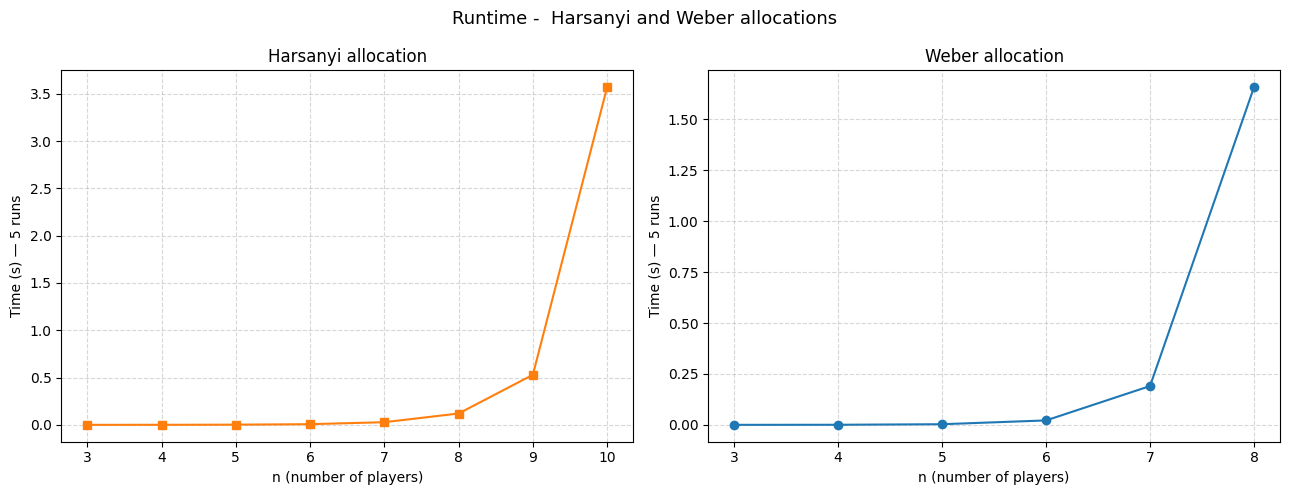

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1 : Harsanyi ---
axes[0].plot(range(3,11), time_harsanyi, marker='s', color='tab:orange')
axes[0].set_xlabel('n (number of players)')
axes[0].set_ylabel('Time (s) — 5 runs')
axes[0].set_title('Harsanyi allocation')
axes[0].set_xticks(range(3,11))
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2 : Weber ---
axes[1].plot(range(3,9), time_weber, marker='o', color='tab:blue')
axes[1].set_xlabel('n (number of players)')
axes[1].set_ylabel('Time (s) — 5 runs')
axes[1].set_title('Weber allocation')
axes[1].set_xticks(range(3,9))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Runtime -  Harsanyi and Weber allocations', fontsize=13)
plt.tight_layout()
plt.show()

We indeed observe an exponential increase in the runtine w.r.t. the number of players.

## Shapley values

We can break this exponential increase by **sampling permutations**. Doing this effectively **samples a subset of coalitions**.

In [18]:
def shapley_sample_permutation(value_function, d:int):
    """
    Returns a permutation from {1,...,d} drawn uniformly

    Args:
        value_function: A value function (not used here).
        d (int): Total number of players

    Returns:
        tuple: A permutation drawn with probability 1/d!
    """
    return tuple(int(x) for x in np.random.permutation(d) + 1)

def approximated_allocation(perm_sampling_function, m: int, pmf, value_function, d:int):
    """
    Returns an approximated allocation using the Weber set formula.

    Args:
        perm_sampling_function: Function that returns a permutation wrt pmf
        m (int): number of
        value_function: A value function.
        pmf: A probability mass function over the set of permutations
        d (int): The total number of players

    Returns:
        list: Returns the approximated allocation using the Weber set framework.
    """
    # Compute and store all permutations
    selected_perms = [perm_sampling_function(value_function, d) for i in range(m)]

    # Intialize the allocation vector
    allocation = [0.0] * d

    for perm in selected_perms:
        for i in range(d):
            player_id = i + 1
            allocation[i] += 1/m * get_marginal_contribution(perm, value_function, player_id)

    return allocation


In [19]:
np.random.seed(12345)
time_harsanyi = [timeit.timeit(lambda:get_harsanyi_allocation(coalition_size, n, shapley_weight_system), number=10) for n in range(3,11)]
time_approx = [timeit.timeit(lambda:approximated_allocation(shapley_sample_permutation, 300, shapley_pmf, coalition_size, n), number=100) for n in range(3,11)]

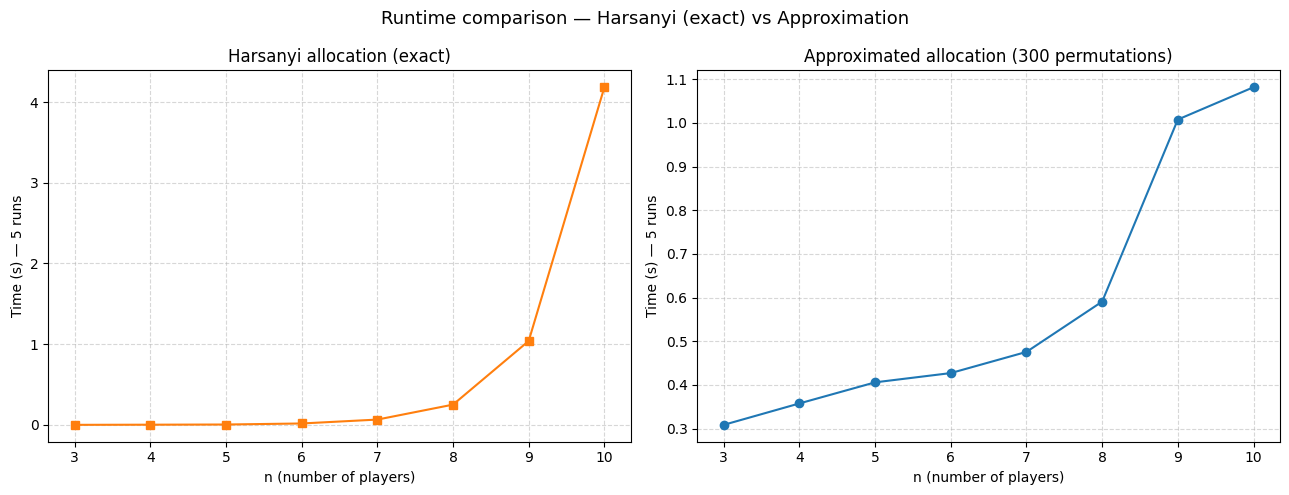

In [20]:
ns = list(range(3, 11))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1 : Harsanyi ---
axes[0].plot(ns, time_harsanyi, marker='s', color='tab:orange')
axes[0].set_xlabel('n (number of players)')
axes[0].set_ylabel('Time (s) — 5 runs')
axes[0].set_title('Harsanyi allocation (exact)')
axes[0].set_xticks(ns)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2 : Approximation ---
axes[1].plot(ns, time_approx, marker='o', color='tab:blue')
axes[1].set_xlabel('n (number of players)')
axes[1].set_ylabel('Time (s) — 5 runs')
axes[1].set_title('Approximated allocation (300 permutations)')
axes[1].set_xticks(ns)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Runtime comparison — Harsanyi (exact) vs Approximation', fontsize=13)
plt.tight_layout()
plt.show()

We can see that the runtine dependence wrt the number of players becomes linear (albeit still proportional to $m$). Let's visualize if the approximation scheme does actually approximate the true values.

In [21]:
np.random.seed(12345)

# Let's define a different value function
def sum_value_function(coalition):
    # Returns the square root of the sum of the players
    return(np.sqrt(sum(coalition)))

d = 11
sample_sizes = list(range(100, 1501, 100))
n_rep = 100

# True allocation
true_alloc = get_harsanyi_allocation(sum_value_function, d, shapley_weight_system)

approx_allocs = [
    [approximated_allocation(shapley_sample_permutation, m, shapley_pmf, sum_value_function, d)
     for _ in range(n_rep)]
    for m in sample_sizes
]

mean_allocs = np.array([np.mean(reps, axis=0) for reps in approx_allocs])
std_allocs  = np.array([np.std(reps,  axis=0) for reps in approx_allocs])

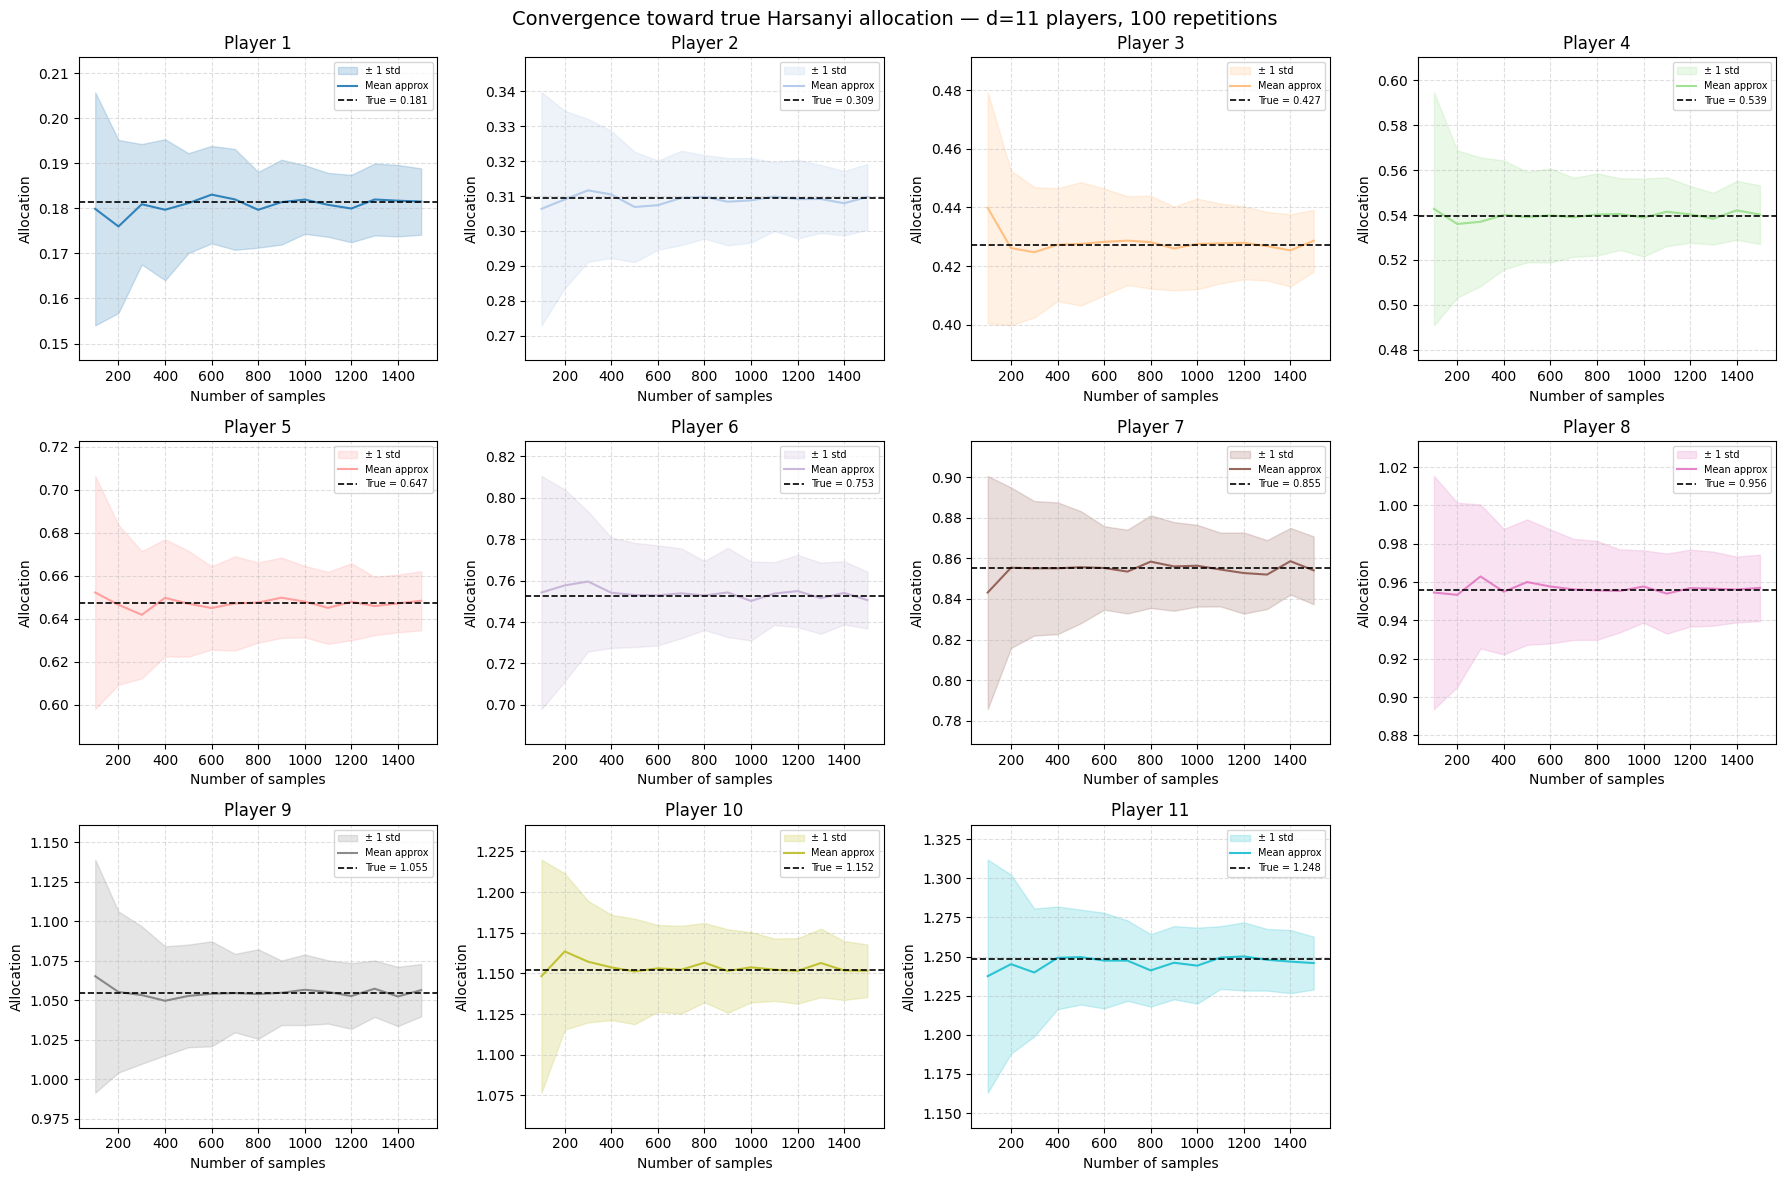

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
colors = [plt.cm.tab20(i / d) for i in range(d)]

for i in range(d):
    ax = axes[i]
    lo = mean_allocs[:, i] - std_allocs[:, i]
    hi = mean_allocs[:, i] + std_allocs[:, i]

    # Fixer le ylim avant axhline
    y_min = min(lo.min(), true_alloc[i])
    y_max = max(hi.max(), true_alloc[i])
    margin = 0.15 * (y_max - y_min) if y_max != y_min else 0.1
    ax.set_ylim(y_min - margin, y_max + margin)

    ax.fill_between(sample_sizes, lo, hi, color=colors[i], alpha=0.2, label='± 1 std')
    ax.plot(sample_sizes, mean_allocs[:, i], color=colors[i], alpha=0.9, label='Mean approx')
    ax.axhline(true_alloc[i], color='black', linestyle='--', linewidth=1.2, label=f'True = {true_alloc[i]:.3f}')

    ax.set_title(f'Player {i+1}')
    ax.set_xlabel('Number of samples')
    ax.set_ylabel('Allocation')
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_visible(False)

fig.suptitle(f'Convergence toward true Harsanyi allocation — d={d} players, {n_rep} repetitions', fontsize=14)
plt.tight_layout()
plt.show()

# R² decomposition: Lindeman-Merenda-Gold (LMG)

Let's start with loading a dataset, running a linear regression model, and return the $R^2$ coefficient.

In [22]:
from sklearn.datasets import fetch_california_housing

# We are going to use the California Housing dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)

# We fit a linear regression model
model = LinearRegression().fit(X_train, y_train)

# We compute the R^2
r2_full = r2_score(y_test, model.predict(X_test))
r2_full

0.58970650064299

In the California Housing Dataset, we have $d=8$ features.

In [23]:
d = X.shape[1]
d

8

The value function for the LMG indices is the $R^2$ of the nested model only using covariates in the coalition.

In [24]:
def lmg_value_function(coalition, X_tr, X_te, Y_tr, Y_te):
    """
    Computes the R² on a test dataset using only a subset of covariates
    Args:
        coalition (set): Indices of the subset of covariates
        X_tr : Training dataset
        X_te : Test dataset
        Y_tr : Training target
        Y_te : Test targer

    Returns:
        float: R² of the linear model fitted only using the covariates in coalition
    """
    if not coalition:
        return 0
    else:
        select_variables = [i-1 for i in coalition]
        X_A_tr = X_tr[:, select_variables]
        X_A_te = X_te[:, select_variables]

        model = LinearRegression().fit(X_A_tr, Y_tr)
        r2 = r2_score(Y_te, model.predict(X_A_te))
        return(r2)

Now let's compute all value functions at once.

In [25]:
coalitions = get_coalitions(d)

lmg_values_unnormalized = [lmg_value_function(coalition, X_train, X_test, y_train, y_test) for coalition in coalitions]
r2_full = lmg_values_unnormalized[len(coalitions)-1]
lmg_values = [value/r2_full for value in lmg_values_unnormalized]

We are going to use the following equivalent formula to compute the Shapley values:

$$\textrm{Shap}(i) = \frac{1}{d} \sum_{A \subseteq D \setminus {i}} {n-1 \choose |A|}^{-1} \left[ v(A \cup \{i\} ) - v(A) \right] $$

It is computationnally a little bit more efficient that the Harsanyi and Weber formulation

In [26]:
lmg_indices = [0]*d

for i in range(len(coalitions)):
    coalition = coalitions[i]
    if not coalitions[i]: # if coalition = emptyset
        continue
    else:
        for j in range(d):
            player = j+1
            if player in coalition:
                lmg_indices[j] += 1/d * lmg_values[i] * 1 / comb(d - 1, len(coalition)-1)
            else:
                lmg_indices[j] -= 1/d * lmg_values[i] * 1 / comb(d - 1, len(coalition))

Let's verify that the LMG indices sum to 1, because we divided the value function by the $R^2$ of the full model:

In [27]:
sum(lmg_indices)

0.9999999999999997

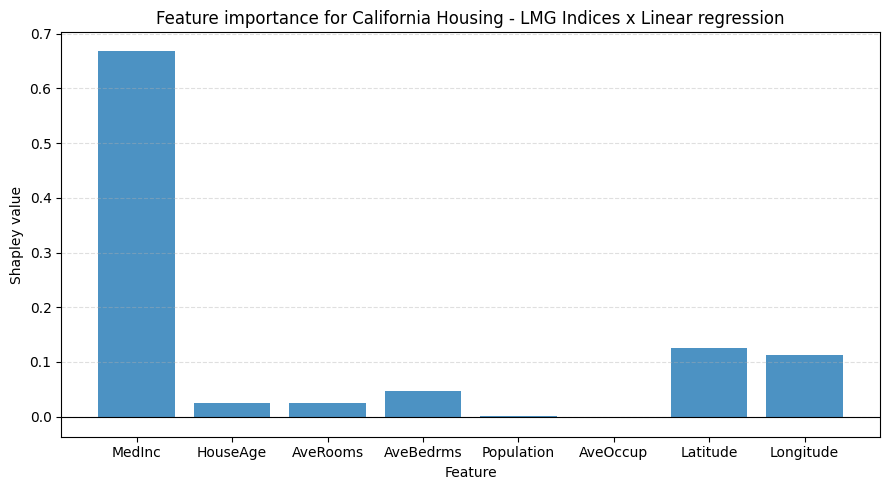

In [28]:
feature_names = fetch_california_housing().feature_names

plt.figure(figsize=(9, 5))
plt.bar(feature_names, lmg_indices, color='tab:blue', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Feature')
plt.ylabel('Shapley value')
plt.title('Feature importance for California Housing - LMG Indices x Linear regression')
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

Now, let's wrap everything to define a more efficient way to compute the Shapley values.

In [30]:
def lmg_indices(X, y, seed:int=12345):
    """
    Returns the lmg indices

    Args:
        X: Covariates (np.array)
        y: Target (np.array)
        seed (int): seed for the random split

    Returns:
        list: Returns the lmg indices
    """
    d = X.shape[1]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    coalitions = get_coalitions(d)
    lmg_values_unnormalized = [lmg_value_function(coalition, X_train, X_test, y_train, y_test) for coalition in coalitions]
    r2_full = lmg_values_unnormalized[len(coalitions)-1]
    lmg_values = [value/r2_full for value in lmg_values_unnormalized]

    lmg_indices = [0]*d

    for i in range(len(coalitions)):
        coalition = coalitions[i]
        if not coalitions[i]: # if coalition = emptyset
            continue
        else:
            for j in range(d):
                player = j+1
                if player in coalition:
                    lmg_indices[j] += 1/d * lmg_values[i] * 1 / comb(d - 1, len(coalition)-1)
                else:
                    lmg_indices[j] -= 1/d * lmg_values[i] * 1 / comb(d - 1, len(coalition))
    return(lmg_indices)

In [31]:
lmg_indices(X,y, 42)

[0.6396562899914032,
 0.02787836966265786,
 0.05077524427945207,
 0.030360111662403808,
 0.0009092015028836636,
 0.0014115445538681742,
 0.1368164013303852,
 0.11219283701694652]

Now, it's your turn: Pick any dataset and compute their LMG indices !

In [32]:
# Extract any tabular model using one of the function provided by: https://scikit-learn.org/stable/api/sklearn.datasets.html

# For instance, the diabetes dataset
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)

In [33]:
# Now compute the LMG indices!
lmg_indices(X,y, 42)

[-0.01376641179565996,
 0.010063542880091841,
 0.23268572026486967,
 0.09270459413905496,
 0.03572801284083765,
 0.028067247984643412,
 0.1171954106775193,
 0.08715859434633573,
 0.3488075538139022,
 0.06135573484840495]

# Your time to shine

Define your own value function, and compute their Shapley values using the following function.

In [ ]:
def my_awesome_value_function(coalition, X_tr, X_te, Y_tr, Y_te):
    """
    Computes an awesome value function

    Args:
        coalition (set): Indices of the subset of covariates
        X_tr : Training dataset
        X_te : Test dataset
        Y_tr : Training target
        Y_te : Test targer

    Returns:
        float: An awesome value function
    """

    if not coalition:
      return 0
    else:
      # Code your value function here
      return 1


def shapley_values(X, y, value_function, seed:int=12345):
    """
    Returns the Shapley values for any value function

    Args:
        X: Covariates (np.array)
        y: Target (np.array)
        value_function: A value function.
        seed (int): seed for the random split

    Returns:
        list: Returns the Shapley values
    """
    d = X.shape[1]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    coalitions = get_coalitions(d)
    values = [value_function(coalition, X_train, X_test, y_train, y_test) for coalition in coalitions]

    shapley_values = [0]*d

    for i in range(len(coalitions)):
        coalition = coalitions[i]
        if not coalitions[i]: # if coalition = emptyset
            continue
        else:
            for j in range(d):
                player = j+1
                if player in coalition:
                    shapley_values[j] += 1/d * values[i] * 1 / comb(d - 1, len(coalition)-1)
                else:
                    shapley_values[j] -= 1/d * values[i] * 1 / comb(d - 1, len(coalition))
    return(shapley_values)

[0.1,
 0.1,
 0.1,
 0.10000000000000002,
 0.10000000000000002,
 0.1,
 0.10000000000000003,
 0.10000000000000003,
 0.10000000000000003,
 0.10000000000000003]